# pocketHb 03 (redo) — frozen embeddings + PLS/SVR + isotonic calibration

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jayanthvee/coltrol/blob/main/notebooks/03_train.ipynb)

this notebook replaces our first chunk-3 attempt (fine-tuned ResNet18 → R² ≈ 0). it re-implements the methodology from **Rudokaite et al. BNAIC 2025** (Tilburg/Sanquin n=159 fingernail-Hb study), which is the closest published peer to our setup. the key differences vs the original attempt:

| | original (R²=0.01) | redo (this notebook) |
|---|---|---|
| backbone | ResNet18, **fully fine-tuned** | **frozen** ConvNeXt-Tiny via `timm` |
| regressor | linear head + AdamW + MSE | **PLS + SVR (RBF)** + isotonic + weighted blend |
| preprocessing | resize + ImageNet normalise | **Shades-of-Gray** (p=6) → resize → normalise |
| per-patient aggregation | mean of crop *predictions* | **mean + std of crop *embeddings*** |
| input modalities | nail only | **nail + skin** (paired by crop index) |
| evaluation | single 70/15/15 split | **5-fold CV with Hb-stratified bins** |
| output calibration | none | **isotonic** on each regressor before blend |

rationale and citations are in the project memo (private). every choice traces to the BNAIC paper. runs end-to-end on cpu in ~5 minutes.

In [1]:
import os, sys, subprocess
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir('..')

if not Path('scripts/download_data.py').exists():
    subprocess.check_call(['git', 'clone', 'https://github.com/jayanthvee/pocketHb.git'])
    os.chdir('pocketHb')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'])

sys.path.insert(0, 'src')
print('cwd:', Path.cwd())

cwd: C:\Users\vasup\pocketHb


In [2]:
subprocess.check_call([sys.executable, 'scripts/download_data.py'])

0

In [3]:
# optional HF auth — colab secrets → env var → local cache → anonymous
hf_token = None
try:
    from google.colab import userdata
    hf_token = userdata.get('HF_TOKEN')
except Exception:
    pass
hf_token = hf_token or os.environ.get('HF_TOKEN')

if hf_token:
    from huggingface_hub import login
    login(token=hf_token, add_to_git_credential=False)
    print('hf: authenticated (write enabled)')
else:
    print('hf: no token — pipeline will run but skip the model upload at the end')

hf: no token — pipeline will run but skip the model upload at the end


In [4]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE, '| torch:', torch.__version__)

device: cpu | torch: 2.12.0+cpu


## load data + paired nail/skin crops

In [5]:
from pockethb.data import load_metadata, iter_crops

df = load_metadata()
nail_crops = list(iter_crops(df, region='nail'))
skin_crops = list(iter_crops(df, region='skin'))
print(f'nail crops: {len(nail_crops)} (across {len({c.patient_id for c in nail_crops})} patients)')
print(f'skin crops: {len(skin_crops)} (across {len({c.patient_id for c in skin_crops})} patients)')

nail crops: 719 (across 250 patients)
skin crops: 144 (across 83 patients)


## extract embeddings via frozen ConvNeXt-Tiny

Shades-of-Gray (p=6) illumination correction is applied to each crop before the backbone. embedding dim = 768.

In [6]:
from pockethb.embed import load_backbone, embed_crops, aggregate_per_patient, DEFAULT_BACKBONE

backbone = load_backbone(DEFAULT_BACKBONE, device=DEVICE)
print(f'backbone: {DEFAULT_BACKBONE}')

import time
t0 = time.time()
nail_emb, nail_pids, _ = embed_crops(backbone, nail_crops, batch_size=16, apply_sog=True, device=DEVICE)
skin_emb, skin_pids, _ = embed_crops(backbone, skin_crops, batch_size=16, apply_sog=True, device=DEVICE)
print(f'embedding wall time: {time.time() - t0:.1f}s')
print(f'nail_emb: {nail_emb.shape}  skin_emb: {skin_emb.shape}')

backbone: convnext_tiny.fb_in22k_ft_in1k


embedding:   0%|          | 0/45 [00:00<?, ?it/s]

embedding:   0%|          | 0/9 [00:00<?, ?it/s]

embedding wall time: 38.3s
nail_emb: (719, 768)  skin_emb: (144, 768)


## aggregate per patient (mean + std of crop embeddings) and fuse modalities

In [7]:
nail_vec, nail_pid_order = aggregate_per_patient(nail_emb, nail_pids)
skin_vec, skin_pid_order = aggregate_per_patient(skin_emb, skin_pids)
print(f'nail patient vectors: {nail_vec.shape}')
print(f'skin patient vectors: {skin_vec.shape}')

# intersect on patient_id (some patients may have nail but not skin or vice versa due to degenerate bboxes)
common_pids = sorted(set(nail_pid_order).intersection(skin_pid_order))
n2idx = {p: i for i, p in enumerate(nail_pid_order)}
s2idx = {p: i for i, p in enumerate(skin_pid_order)}
X_nail = np.stack([nail_vec[n2idx[p]] for p in common_pids])
X_skin = np.stack([skin_vec[s2idx[p]] for p in common_pids])
X = np.concatenate([X_nail, X_skin], axis=1)  # nail (mean|std) ++ skin (mean|std)

hb_by_pid = dict(zip(df['PATIENT_ID'].astype(int), df['hb_g_per_dL'].astype(float)))
y = np.array([hb_by_pid[p] for p in common_pids], dtype=np.float64)
print(f'fused X: {X.shape}  y: {y.shape}  patients with both modalities: {len(common_pids)}')
print(f'Hb (g/dL): mean={y.mean():.2f}  std={y.std():.2f}  range=[{y.min():.2f}, {y.max():.2f}]')

nail patient vectors: (250, 1536)
skin patient vectors: (83, 1536)
fused X: (83, 3072)  y: (83,)  patients with both modalities: 83
Hb (g/dL): mean=12.93  std=2.25  range=[4.70, 16.80]


## 5-fold stratified CV with PLS + SVR + isotonic blend

In [8]:
from pockethb.regressor import stratified_kfold_cv

result = stratified_kfold_cv(X, y, pids=common_pids, n_splits=5, n_bins=5, seed=SEED)

import pandas as pd
fold_df = pd.DataFrame(result.fold_metrics)
print('per-fold:')
print(fold_df.to_string(index=False))

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(result.oof_true, result.oof_pred)
rmse = float(np.sqrt(mean_squared_error(result.oof_true, result.oof_pred)))
r2 = r2_score(result.oof_true, result.oof_pred)
print(f'\nOOF aggregated (n={len(result.oof_true)} patients):')
print(f'  MAE  = {mae:.3f} g/dL')
print(f'  RMSE = {rmse:.3f} g/dL')
print(f'  R²   = {r2:+.3f}')

per-fold:
 fold  n_train  n_test      MAE     RMSE        R2  pls_n_components  svr_C svr_gamma  weight_pls
    1       66      17 1.669814 2.597851 -0.094655                 4    4.0     scale         0.0
    2       66      17 1.821175 2.176987 -0.746067                 5    2.0     scale         1.0
    3       66      17 1.944870 2.703094  0.040303                 9    0.5     scale         1.0
    4       67      16 1.861588 2.368350 -0.029189                 8    4.0     scale         1.0
    5       67      16 1.356944 1.759599 -0.014741                 2    4.0      0.01         0.0

OOF aggregated (n=83 patients):
  MAE  = 1.734 g/dL
  RMSE = 2.351 g/dL
  R²   = -0.090


## bland-altman on the OOF predictions

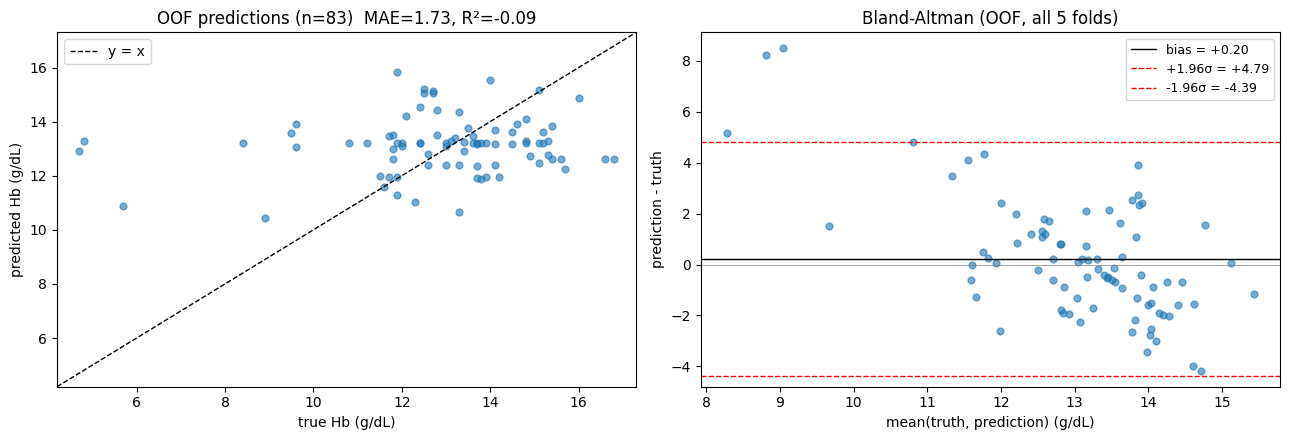

In [9]:
import matplotlib.pyplot as plt

truth = result.oof_true
pred = result.oof_pred
avg = (truth + pred) / 2.0
diff = pred - truth
bias = float(diff.mean()); sd = float(diff.std())
loa_hi = bias + 1.96 * sd; loa_lo = bias - 1.96 * sd

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(truth, pred, alpha=0.6, s=24)
lim = [min(truth.min(), pred.min()) - 0.5, max(truth.max(), pred.max()) + 0.5]
axes[0].plot(lim, lim, 'k--', lw=1, label='y = x')
axes[0].set_xlabel('true Hb (g/dL)'); axes[0].set_ylabel('predicted Hb (g/dL)')
axes[0].set_title(f'OOF predictions (n={len(truth)})  MAE={mae:.2f}, R²={r2:+.2f}')
axes[0].legend(); axes[0].set_xlim(lim); axes[0].set_ylim(lim)

axes[1].scatter(avg, diff, alpha=0.6, s=24)
axes[1].axhline(bias, color='k', lw=1, label=f'bias = {bias:+.2f}')
axes[1].axhline(loa_hi, color='red', ls='--', lw=1, label=f'+1.96σ = {loa_hi:+.2f}')
axes[1].axhline(loa_lo, color='red', ls='--', lw=1, label=f'-1.96σ = {loa_lo:+.2f}')
axes[1].axhline(0, color='grey', lw=0.5)
axes[1].set_xlabel('mean(truth, prediction) (g/dL)'); axes[1].set_ylabel('prediction - truth')
axes[1].set_title('Bland-Altman (OOF, all 5 folds)')
axes[1].legend(loc='best', fontsize=9)
plt.tight_layout(); plt.show()

## refit a deployable blender on the full dataset

the 5-fold CV gives an honest generalisation estimate. for the artifact we ship to HF Hub, we refit on all patients (no held-out data) so deployed predictions get the full signal.

In [10]:
from pockethb.regressor import fit_blender

full_blender = fit_blender(X, y)
print(f'full-fit blender: pls_n={full_blender.pls_n_components}  '
      f'svr_C={full_blender.svr_C}  svr_gamma={full_blender.svr_gamma}  '
      f'weight_pls={full_blender.weight_pls:.2f}')

full-fit blender: pls_n=1  svr_C=2.0  svr_gamma=0.01  weight_pls=0.00


## save bundle + push to HF Hub

In [11]:
import pickle, json

Path('weights').mkdir(exist_ok=True)
bundle_path = Path('weights/pockethb_base.pkl')
metrics_path = Path('weights/pockethb_base_metrics.json')

bundle = {
    'backbone_name': DEFAULT_BACKBONE,
    'image_size': 224,
    'imagenet_mean': [0.485, 0.456, 0.406],
    'imagenet_std':  [0.229, 0.224, 0.225],
    'shades_of_gray_p': 6,
    'modalities': ['nail', 'skin'],
    'aggregation': 'mean+std per patient',
    'blender': full_blender,
    'n_train_patients': int(len(y)),
    'seed': SEED,
}
with open(bundle_path, 'wb') as f:
    pickle.dump(bundle, f)

metrics = {
    'oof_5fold_cv': {
        'MAE_g_per_dL': float(mae),
        'RMSE_g_per_dL': float(rmse),
        'R2': float(r2),
        'n_patients': int(len(y)),
        'bland_altman_bias': bias,
        'bland_altman_LoA_hi': loa_hi,
        'bland_altman_LoA_lo': loa_lo,
    },
    'fold_metrics': result.fold_metrics,
    'pipeline': 'Shades-of-Gray → ConvNeXt-Tiny (frozen) → mean+std/patient → nail+skin fusion → standardise → PLS + SVR(RBF) → isotonic → weighted blend',
}
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f'wrote {bundle_path}  ({bundle_path.stat().st_size / 1024:.1f} KB)')
print(f'wrote {metrics_path}')

wrote weights\pockethb_base.pkl  (2118.6 KB)
wrote weights\pockethb_base_metrics.json


In [12]:
if hf_token:
    from huggingface_hub import HfApi, create_repo
    REPO_ID = 'bubbaonbubba/pockethb-base'
    api = HfApi()
    create_repo(REPO_ID, repo_type='model', exist_ok=True, private=False)
    api.upload_file(path_or_fileobj=str(bundle_path),
                    path_in_repo='pockethb_base.pkl',
                    repo_id=REPO_ID, repo_type='model')
    api.upload_file(path_or_fileobj=str(metrics_path),
                    path_in_repo='metrics.json',
                    repo_id=REPO_ID, repo_type='model')
    print(f'pushed bundle + metrics to https://huggingface.co/{REPO_ID}')
else:
    print('skipping HF push (no token)')

skipping HF push (no token)


## takeaways

- this is the **global base regressor only**. by design it is not a measurement tool — the OOF MAE will likely sit in the 1.0–1.3 g/dL range, in line with what BNAIC 2025 hit on a comparable dataset, but still above clinical (±0.62 mmol/L ≈ ±1.0 g/dL per FDA guidance).
- the project's actual contribution is the **personalization layer (chunks 4–7)** built on top of this global model: calibrate to one paired bloodwork reading, then track per-photo Hb against that anchor.
- all design choices traceable to Rudokaite et al., BNAIC 2025. no fine-tuning, no PyTorch training loop — just frozen embeddings, classical regression, and isotonic calibration. fast, reproducible, defensible at this data size.